## E-Commerce Sales Data Cleaning Pipeline

**Author:** Hassan Akhter

## What this script does:

Takes a messy, real-world e-commerce dataset and cleans. It step by step — handling nulls, duplicates, bad formats, wrong data types, and outliers — producing a clean CSV ready for analysis or model training.

**Language:** Python

**Libraries:** pandas, NumPy, re, matplotlib

**Run:** python data_cleaning.py

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
print("Libraries installed Sucessfully!")

Libraries installed Sucessfully!


### Load Data

Read the raw dataset, this is the messy version straight from the source before any cleaning.

In [2]:
df = pd.read_csv("ecommerce_dirty.csv")
df

,order_id,customer_name,email,phone,product,category,quantity,price,order_date,status,country
0,1396,PATRICIA JOHNSON,patricia.johnson@yahoo.com,4149902672,Charger,Electronics,1.0,$1341.68,01/10/2023,CANCELLED,Canada
1,1190,NaN,jennifer.garcia@outlook.com,NaN,Webcam,Accessories,2.0,NaN,11/02/2024,delivered,Canada
2,1163,james wilson,james.wilson@yahoo.com,1786265600,Headphones,accessories,15.0,1077.37,2024-11-07,NaN,NaN
3,1102,John Davis,john.davis@outlook.com,NaN,Mouse,Mobile,18.0,331.72,2023-04-15,Pending,France
4,1362,PATRICIA MILLER,patricia.miller@gmail.com,NaN,Headphones,accessories,1.0,973.11,2023-11-14,shipped,Canada
...,...,...,...,...,...,...,...,...,...,...,...
520,1349,Patricia Jones,patricia.jones@yahoo.com,420-965-2476,Phone,Accessories,9.0,£90.83,21 Jul 2024,delivered,Canada
521,1212,Mary Garcia,mary.garcia@gmail.com,884-774-6119,Speaker,computing,1.0,£292.86,06-29-2024,CANCELLED,USA
522,1048,Barbara Moore,barbara.moore@gmail.com,872-732-1815,Monitor,Audio,19.0,£665.86,2023/08/09,delivered,France
523,1197,John Brown,john.brown@outlook.com,NaN,Monitor,Computing,1.0,£32.47,12-30-2023,NaN,Germany


In [3]:
print(f"Shape        : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nDuplicates   :{df.duplicated().sum()}")
print(f"\nMissing Values per columns:\n{df.isnull().sum()}")
print(f"\nData Types:\n{df.dtypes}")

Shape        : 525 rows x 11 columns

Duplicates   :25

Missing Values per columns:
order_id           0
customer_name     21
email             21
phone            196
product            0
category          23
quantity          24
price             32
order_date        13
status            20
country           18
dtype: int64

Data Types:
order_id           int64
customer_name     object
email             object
phone             object
product           object
category          object
quantity         float64
price             object
order_date        object
status            object
country           object
dtype: object


### Visualize MISSING DATA (Before)

A quick bar chart so we can see exactly which columns have missing data and how bad the problem is!

In [4]:
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0]

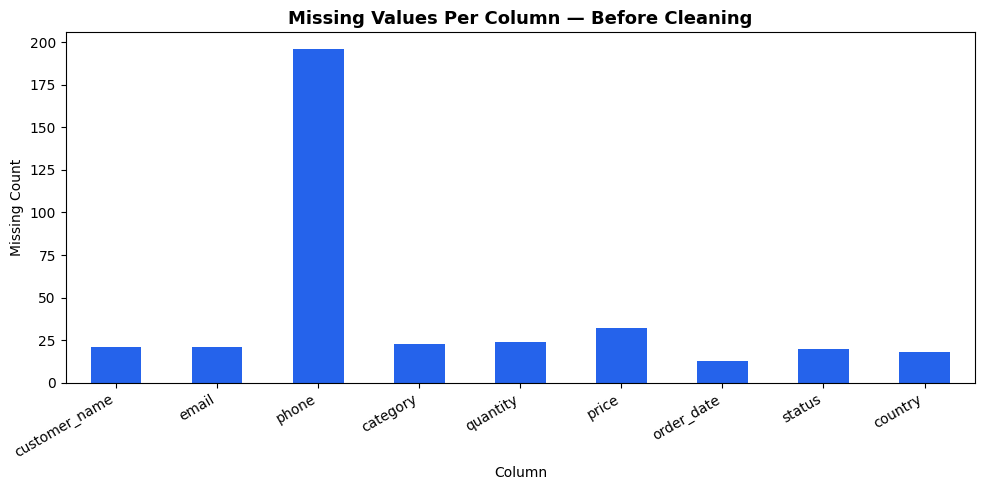

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
missing_before.plot(kind="bar", color="#2563EB", ax=ax)
ax.set_title("Missing Values Per Column — Before Cleaning", fontsize=13, fontweight="bold")
ax.set_ylabel("Missing Count")
ax.set_xlabel("Column")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### STEP 1: Remove Duplicates

Some orders appear more than once in the raw data.

In [6]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"[1] Duplicates removed: {before - len(df)}  |  Rows remaining: {len(df)}")

[1] Duplicates removed: 25  |  Rows remaining: 500


### STEP 2: Customer Name

Names come in ALL CAPS, all lowercase, with extra spaces.

In [7]:
df["customer_name"] = (
    df["customer_name"]
    .str.strip()
    .str.title()
    .fillna("Unknown")
)
print(f"[2] customer_name cleaned  |  Nulls filled: {(df['customer_name'] == 'Unknown').sum()}")

[2] customer_name cleaned  |  Nulls filled: 19


We standardize the customers and fill unknown to nulls.

### STEP 3: Email

We see some emails missing the @ symbol, have no domain, or are placeholder strings like "N/A". I flag those as invalid and replace them with a safe placeholder so they don't break downstream systems that expect a valid email format

In [8]:
def is_valid_email(email):
    
    email = str(email).strip()
    
    # Must contain exactly one "@"
    if email.count("@") != 1:
        return False
        
    # Split into username and domain
    username, domain = email.split("@")
    
    # Username and domain must not be empty
    if not username or not domain:
        return False
        
    # Domain must contain at least one dot (e.g., "gmail.com")
    if "." not in domain:
        return False
        
    # No spaces allowed
    if " " in email:
        return False
    return True

# Find invalid emails
invalid_email_mask = ~df["email"].apply(is_valid_email)

# Replace them
df.loc[invalid_email_mask, "email"] = "unknown@unknown.com"

print(f"[3] email cleaned  |  Invalid replaced: {invalid_email_mask.sum()}")

[3] email cleaned  |  Invalid replaced: 38


### STEP 4: Phone Number

Phone numbers are stored in at least 4 different formats: (123) 456-7890, 1234567890, 123-456-7890, or just blank.

I extract the digits and reformat everything as XXX-XXX-XXXX. Anything that can't be parsed cleanly is left as NaN.

In [9]:
def clean_phone(phone):
    
    if pd.isna(phone) or str(phone).strip() in ["", "N/A"]:
        return np.nan
        
    digits = re.sub(r"\D", "", str(phone))
    
    if len(digits) == 10:
        
        return f"{digits[:3]}-{digits[3:6]}-{digits[6:]}"
        
    return np.nan  # anything other than 10 digits is unusable

df["phone"] = df["phone"].apply(clean_phone)

print(f"[4] phone cleaned  |  Standardised format: XXX-XXX-XXXX  |  Unparseable: {df['phone'].isna().sum()}")

[4] phone cleaned  |  Standardised format: XXX-XXX-XXXX  |  Unparseable: 186


### STEP 5: Product Category

The same category appears as "Electronics", "ELECTRONICS", and "electronics". Let's standardise to Title Case and fill any missing values with the
most common category.

In [10]:
df["category"] = df["category"].str.strip().str.title()

most_common_category = df["category"].mode()[0]

df["category"] = df["category"].fillna(most_common_category)

print(f"[5] category cleaned  |  Unique values: {sorted(df['category'].unique())}")

[5] category cleaned  |  Unique values: ['Accessories', 'Audio', 'Computing', 'Electronics', 'Mobile']


### STEP 6: Price

Prices are stored inconsistently — some have a $ or £ symbol, some are stored as strings, some are missing entirely. I strip all non-numeric characters, convert to float, and fill missing values with the median (more robust than mean because it's less affected by extreme values)

In [11]:
def clean_price(val):
    # Remove any currency symbol or stray characters, keep digits and decimal
    cleaned = re.sub(r"[^\d.]", "", str(val))
    try:
        return float(cleaned)
    except ValueError:
        return np.nan

df["price"] = df["price"].apply(clean_price)

median_price = df["price"].median()

df["price"] = df["price"].fillna(median_price).round(2)

print(f"[6] price cleaned  |  Median fill: £{median_price:.2f}  |  Nulls filled: {df['price'].isna().sum()}")

[6] price cleaned  |  Median fill: £737.92  |  Nulls filled: 0


### STEP 7: Outlier removal (IQR METHOD)

Extreme price values (e.g. £0.01 or £99999) are likely data entry errors. We use the IQR method to define a reasonable price range and remove anything that falls outside it. IQR = Q3 - Q1, and the accepted range is Q1-1.5*IQR to Q3+1.5*IQR

In [12]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before_outlier = len(df)
df = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)].reset_index(drop=True)
print(f"[7] outliers removed  |  Range: £{lower_bound:.2f}–£{upper_bound:.2f}  |  Removed: {before_outlier - len(df)} rows")

[7] outliers removed  |  Range: £-621.08–£2139.29  |  Removed: 0 rows


### STEP 8: Quantity

Quantity came in as a float column due to missing values (pandas stores NaN as float). I fill nulls with the median and convert back to a proper integer type.

In [13]:
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")

median_qty = df["quantity"].median()

df["quantity"] = df["quantity"].fillna(median_qty).round().astype("Int64")

print(f"[8] quantity cleaned  |  Converted to integer  |  Median fill: {int(median_qty)}")

[8] quantity cleaned  |  Converted to integer  |  Median fill: 2


### STEP 9: Order date

Dates are stored in at least 5 different formats across the dataset (e.g. "01/12/2023", "2023-12-01", "01 Dec 2023"). pandas' to_datetime with dayfirst=True handles most of these. Any dates that still can't be parsed are filled with the mode.

In [14]:
df["order_date"] = pd.to_datetime(df["order_date"], dayfirst=True, errors="coerce")

null_dates = df["order_date"].isna().sum()

mode_date = df["order_date"].mode()[0]

df["order_date"] = df["order_date"].fillna(mode_date)

print(f"[9] order_date standardised  |  Unparseable filled with mode ({mode_date.date()}): {null_dates}")

[9] order_date standardised  |  Unparseable filled with mode (2023-05-07): 388


### STEP 10: Order Status 

Same inconsistent casing issue as category — fix with Title Case

In [15]:
df["status"].unique()

array(['CANCELLED', 'delivered', nan, 'Pending', 'shipped', 'Returned',
       'SHIPPED', 'pending', 'RETURNED', 'Shipped', 'Cancelled',
       'cancelled', 'DELIVERED', 'returned', 'PENDING', 'Delivered'],
      dtype=object)

In [16]:
df["status"] = df["status"].str.strip().str.title().fillna("Unknown")
print(f"[10] status cleaned  |  Unique values: {sorted(df['status'].unique())}")

[10] status cleaned  |  Unique values: ['Cancelled', 'Delivered', 'Pending', 'Returned', 'Shipped', 'Unknown']


### STEP 11: Country

Standardise country names to Title Case (e.g. "usa" -> "Usa") 

In [17]:
df["country"].unique()

array(['Canada', nan, 'France', 'USA', 'UK', 'Germany'], dtype=object)

In [18]:
df["country"] = df["country"].str.strip().str.title().fillna("Unknown")
print(f"[11] country cleaned  |  Unique values: {sorted(df['country'].unique())}")

[11] country cleaned  |  Unique values: ['Canada', 'France', 'Germany', 'Uk', 'Unknown', 'Usa']


### Final Summary of the Cleaned dataset

In [19]:
# A quick check to confirm cleaning worked as expected

print("\n" + "=" * 55)
print("CLEANING COMPLETE")
print("=" * 55)

print(f"\nFinal shape  : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nDuplicates   : {df.duplicated().sum()}")
print(f"\nMissing values remaining:\n{df.isnull().sum()}")


CLEANING COMPLETE

Final shape  : 500 rows x 11 columns

Duplicates   : 0

Missing values remaining:
order_id           0
customer_name      0
email              0
phone            186
product            0
category           0
quantity           0
price              0
order_date         0
status             0
country            0
dtype: int64


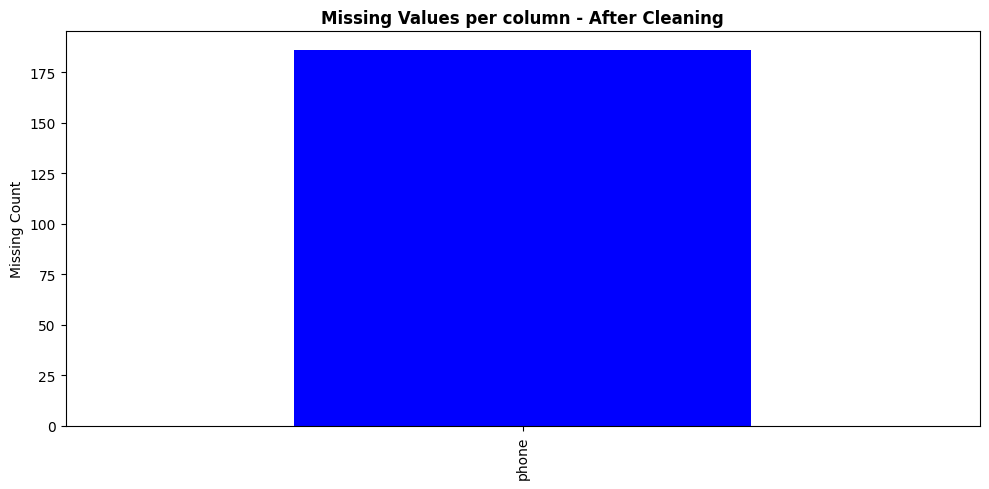


 Note: 'phone' nulls remain are genuinely missing numbers.

 It's not a cleaning error. They have been left as NaN intentionally.


In [20]:
missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0]

if not missing_after.empty:
    fig, ax = plt.subplots(figsize =(10,5))
    missing_after.plot(kind= "bar", color = "blue", ax=ax)
    ax.set_title("Missing Values per column - After Cleaning", fontsize = 12, fontweight = "bold")
    ax.set_ylabel("Missing Count")
    plt.tight_layout()
    plt.show()
    print("\n Note: 'phone' nulls remain are genuinely missing numbers.")
    print("\n It's not a cleaning error. They have been left as NaN intentionally.")
else:
    print("\n All columns fully clean - no missing values remain!")

### Save clean dataset

Export the cleaned dataset, now we can use this to load into a database(perform analysis), or to train a model


In [21]:
df.to_csv("ecommerce_clean.csv", index=False)
print("\nSaved cleaned dataset --> ecommerce_clean.csv")


Saved cleaned dataset --> ecommerce_clean.csv
